# 03 — Training and deploying a surrogate

The full loop: sweep a parametrized "solver" exporting datasets → train an MLP on the
export → save it as TorchScript → deploy it **inside a Kratos solution loop** with
`InferenceProcess`, and warm-start with `HybridInitializationProcess`.

The "solver" is analytic — `PRESSURE(x) = α · sin(πx)` on a 1D line — so surrogate
accuracy is exactly measurable.

> **Prerequisites**: a compiled Kratos with `PhysicsNeMoApplication` enabled and, on the
> environment running this notebook:
>
> ```bash
> export PYTHONPATH=/path/to/Kratos/bin/Release
> export LD_LIBRARY_PATH=/path/to/Kratos/bin/Release/libs:$LD_LIBRARY_PATH
> pip install torch nvidia-physicsnemo   # optional runtime dependencies of the application
> ```
>
> Everything below runs on CPU in a few seconds; outputs are written to `./output/`.

In [1]:
import math
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
from KratosMultiphysics.PhysicsNeMoApplication.processes.export.dataset_export_process import DatasetExportProcess
from KratosMultiphysics.PhysicsNeMoApplication.training.torch_dataset import CreateNpzDataset
from KratosMultiphysics.PhysicsNeMoApplication.processes.inference import inference_process
from KratosMultiphysics.PhysicsNeMoApplication.processes.inference import hybrid_initialization_process

torch.manual_seed(0)
numpy.random.seed(0)
Path("output").mkdir(exist_ok=True)
N_NODES = 21

 |  /           |                  
 ' /   __| _` | __|  _ \   __|    
 . \  |   (   | |   (   |\__ \  
_|\_\_|  \__,_|\__|\___/ ____/
           Multi-Physics 10.4."2"-physicsnemo-application-e03638205c2-Release-x86_64
           Compiled for GNU/Linux and Python3.12 with GCC-13.3
Compiled with threading and MPI support. Threading support with OpenMP.
Maximum number of threads: 2.
Running without MPI.
Importing    KratosPhysicsNeMoApplication 
 ______  _                _            ______        ______                           _ _                 _            
(_____ \| |              (_)          |  ___ \      |  ___ \         /\              | (_)           _   (_)            
 _____) ) | _  _   _  ___ _  ____  ___| |   | | ____| | _ | | ___   /  \  ____  ____ | |_  ____ ____| |_  _  ___  ____  
|  ____/| || \| | | |/___) |/ ___)/___) |   | |/ _  ) || || |/ _ \ / /\ \|  _ \|  _ \| | |/ ___) _  |  _)| |/ _ \|  _ \
| |     | | | | |_| |___ | ( (___|___ | |   | ( (/ /| || || | |_| | |

## The "solver" and the training sweep

Input field: `DISPLACEMENT = (x, α, 0)` per node (coordinates + parameter, packed into
a nodal vector so the surrogate sees both). Target: `PRESSURE = α·sin(πx)`. One export
per α, all into the same dataset directory.

In [2]:
def run_case(model_part, alpha):
    for node in model_part.Nodes:
        node.SetSolutionStepValue(Kratos.DISPLACEMENT, [node.X, alpha, 0.0])
        node.SetSolutionStepValue(Kratos.PRESSURE, alpha * math.sin(math.pi * node.X))

def new_model_part(model):
    model_part = model.CreateModelPart("Main")
    model_part.AddNodalSolutionStepVariable(Kratos.DISPLACEMENT)
    model_part.AddNodalSolutionStepVariable(Kratos.PRESSURE)
    for i in range(N_NODES):
        model_part.CreateNewNode(i + 1, i / (N_NODES - 1), 0.0, 0.0)
    return model_part

training_alphas = numpy.linspace(0.2, 2.0, 10)
for run, alpha in enumerate(training_alphas):
    model = Kratos.Model()
    model_part = new_model_part(model)
    run_case(model_part, alpha)
    model_part.ProcessInfo[Kratos.STEP] = 1
    model_part.ProcessInfo[Kratos.TIME] = 0.0
    settings = Kratos.Parameters("""{
        "model_part_name" : "Main",
        "list_of_fields"  : [
            { "variable_name" : "DISPLACEMENT", "data_location" : "node_historical" },
            { "variable_name" : "PRESSURE",     "data_location" : "node_historical" }
        ],
        "output_path"     : "output/sweep",
        "output_interval" : 1
    }""")
    settings.AddString("file_prefix", f"run{run}")
    export = DatasetExportProcess(model, settings)
    export.ExecuteInitialize()
    export.ExecuteFinalizeSolutionStep()

print(len(list(Path("output/sweep").glob("*.npz"))), "samples exported")

10 samples exported


## Training a small MLP

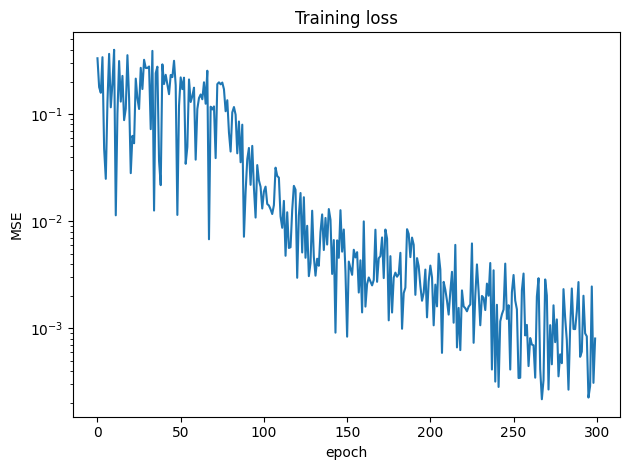

final loss: 0.0008058808539841997


In [3]:
dataset = CreateNpzDataset("output/sweep",
                           input_keys=["DISPLACEMENT__node_historical"],
                           output_keys=["PRESSURE__node_historical"])
loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)

surrogate = torch.nn.Sequential(
    torch.nn.Linear(3, 64), torch.nn.Tanh(),
    torch.nn.Linear(64, 64), torch.nn.Tanh(),
    torch.nn.Linear(64, 1)).double()
optimizer = torch.optim.Adam(surrogate.parameters(), lr=2e-3)

losses = []
for epoch in range(300):
    for inputs, targets in loader:
        optimizer.zero_grad()
        loss = torch.nn.functional.mse_loss(surrogate(inputs.double().reshape(-1, 3)),
                                            targets.double().reshape(-1, 1))
        loss.backward()
        optimizer.step()
    losses.append(loss.item())

plt.semilogy(losses)
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("Training loss")
plt.tight_layout(); plt.savefig("output/loss.png", dpi=120); plt.show()
print("final loss:", losses[-1])
assert losses[-1] < 1e-2, f"training did not converge: final loss {losses[-1]:.3e}"

## Saving the checkpoint

TorchScript is the default checkpoint type of `model_registry.LoadModel`; physicsnemo's
self-describing `.mdlus` checkpoints (`checkpoint_type: "physicsnemo"`) work the same way.

In [4]:
torch.jit.script(surrogate).save("output/surrogate.pt")
print("saved output/surrogate.pt")

saved output/surrogate.pt


## Deploying inside the solution loop

`InferenceProcess` is configured exactly like any other Kratos process — in a real run
this JSON lives in the `processes` block of `ProjectParameters.json`. Here the process
is driven manually for an **unseen** α, and the prediction lands in the `PRESSURE`
variable, indistinguishable from a solver-computed value.

max abs error at unseen alpha=1.234: 4.0920e-02


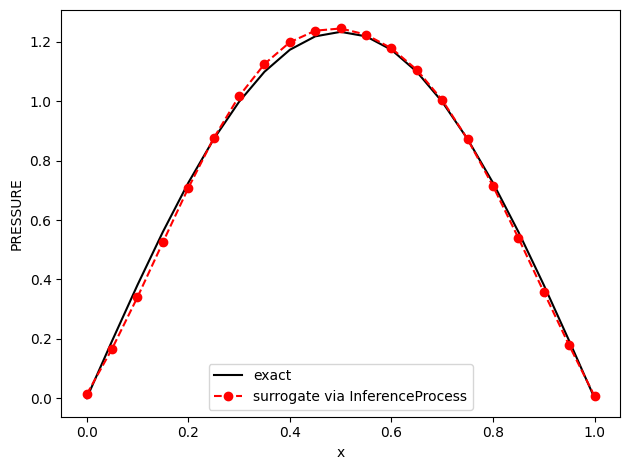

In [5]:
alpha_test = 1.234  # not in the training sweep
model = Kratos.Model()
model_part = new_model_part(model)
for node in model_part.Nodes:
    node.SetSolutionStepValue(Kratos.DISPLACEMENT, [node.X, alpha_test, 0.0])

settings = Kratos.Parameters("""{
    "Parameters": {
        "model_part_name" : "Main",
        "model_settings"  : { "checkpoint_file" : "output/surrogate.pt", "device" : "auto" },
        "input_fields"    : [ { "variable_name" : "DISPLACEMENT", "data_location" : "node_historical" } ],
        "output_fields"   : [ { "variable_name" : "PRESSURE",     "data_location" : "node_historical" } ],
        "execution_point" : "finalize_solution_step",
        "output_interval" : 1
    }
}""")
process = inference_process.Factory(settings, model)
model_part.ProcessInfo[Kratos.STEP] = 1
process.ExecuteFinalizeSolutionStep()

x = numpy.array([node.X for node in model_part.Nodes])
predicted = numpy.array([node.GetSolutionStepValue(Kratos.PRESSURE) for node in model_part.Nodes])
exact = alpha_test * numpy.sin(numpy.pi * x)
error = numpy.abs(predicted - exact).max()
print(f"max abs error at unseen alpha={alpha_test}: {error:.4e}")
assert error < 0.2, f"surrogate does not generalize: max abs error {error:.3e}"

plt.plot(x, exact, "k-", label="exact")
plt.plot(x, predicted, "ro--", label="surrogate via InferenceProcess")
plt.legend(); plt.xlabel("x"); plt.ylabel("PRESSURE")
plt.tight_layout(); plt.savefig("output/prediction.png", dpi=120); plt.show()

### The field on the model part

The same comparison as a render of the model part's nodes: the exact `PRESSURE` and what `InferenceProcess` wrote onto the nodes at the unseen `alpha`.

/home/vicente/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


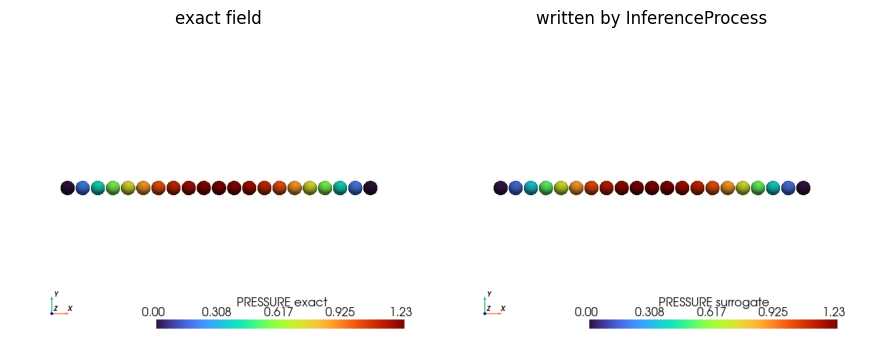

In [6]:
import pyvista as pv
from KratosMultiphysics import pyvista_utilities as pv_utils

def render_points(points, values, title, cmap="turbo", clim=None, point_size=14, view="iso"):
    """Off-screen pyvista render of a point cloud coloured by a scalar (numpy image)."""
    cloud = pv.PolyData(numpy.asarray(points, dtype=float))
    cloud["value"] = numpy.asarray(values, dtype=float).ravel()
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))
    plotter.add_points(cloud, scalars="value", cmap=cmap, clim=clim, point_size=point_size,
                       render_points_as_spheres=True, scalar_bar_args={"title": title})
    plotter.add_axes()
    plotter.view_xy() if view == "xy" else plotter.view_isometric()
    return plotter.screenshot(None)

points = numpy.array([[n.X, n.Y, n.Z] for n in model_part.Nodes])
clim = [float(exact.min()), float(exact.max())]
img_exact = render_points(points, exact, "PRESSURE exact", clim=clim, view="xy", point_size=22)
img_pred = render_points(points, predicted, "PRESSURE surrogate", clim=clim, view="xy", point_size=22)
fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.0))
for ax, (img, title) in zip(numpy.atleast_1d(axes), [(img_exact, 'exact field'), (img_pred, 'written by InferenceProcess')]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.savefig('output/prediction_nodes.png', dpi=120, bbox_inches="tight"); plt.show()


## Warm-starting a solve

`HybridInitializationProcess` is the same machinery pinned to run **exactly once**,
before the solution loop — seeding the first nonlinear solve with the ML prediction
instead of a cold state (fewer iterations to converge).

In [7]:
model = Kratos.Model()
model_part = new_model_part(model)
for node in model_part.Nodes:
    node.SetSolutionStepValue(Kratos.DISPLACEMENT, [node.X, alpha_test, 0.0])

settings = Kratos.Parameters("""{
    "Parameters": {
        "model_part_name" : "Main",
        "model_settings"  : { "checkpoint_file" : "output/surrogate.pt", "device" : "auto" },
        "input_fields"    : [ { "variable_name" : "DISPLACEMENT", "data_location" : "node_historical" } ],
        "output_fields"   : [ { "variable_name" : "PRESSURE",     "data_location" : "node_historical" } ]
    }
}""")
warm_start = hybrid_initialization_process.Factory(settings, model)
warm_start.ExecuteBeforeSolutionLoop()   # the one and only inference
initial_guess = model_part.GetNode(11).GetSolutionStepValue(Kratos.PRESSURE)
print(f"midpoint initial guess = {initial_guess:.4f} (exact: {alpha_test * math.sin(math.pi * 0.5):.4f})")

midpoint initial guess = 1.2453 (exact: 1.2340)
